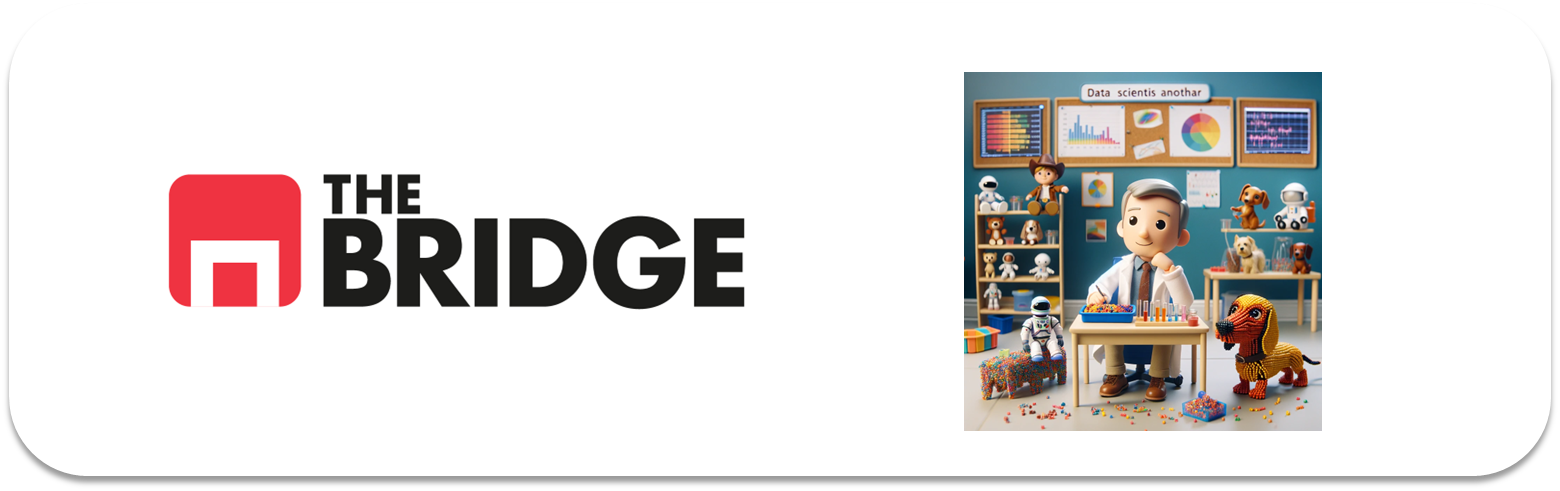

## PRACTICA OBLIGATORIA: **Análisis Univariante**

* La práctica obligatoria de esta unidad consiste en hacer el análisis univariante completo de un dataset con el que acabarás muy familiarizado, el manifiesto de pasajeros del Titanic. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook. Te dejo una que vas a necesitar sí o sí

In [1]:

import pandas as pd
import seaborn as sns

from bootcampviztools import pinta_distribucion_categoricas, plot_combined_graphs

pd.options.mode.copy_on_write = True # CoW por defecto a partir de pandas 3.0.0

### #1 Preparación


### #1.1


Carga en un dataframe los datos del titanic a partir de un dataset de seaborn. Para ello:

* ejecuta ```python sns.get_dataset_names()```
* localiza el nombre que puede ser el adecuado para el ejercicio
* Asigna la salida de ```sns.load_dataset(<nombre_del_dataset>)``` a una variable "df_titanic"

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [6]:
df_titanic = sns.load_dataset("titanic")

In [7]:
df = df_titanic.copy()

### #1.2

Muestra una porción del dataset ("df_titanic") y su info general. ¿Hay nulos?

In [8]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [ ]:
# Podemos ver que hay nulos con el info() pero los contaremos con isna()
df.info()

In [9]:
df.isna().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

### #1.3

Obtén el porcentaje de nulos y decide que hacer con las columnas con nulos y ejecútalo. Además deshazte de la columna "parch" que no la emplearemos.

In [10]:
(df.isna().sum() / len(df) * 100).round(2).sort_values(ascending=False)[:4]

deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
dtype: float64

In [11]:
# Podemos guardar la información en un diccionario
dict_con_nulos = (df.isna().sum() / len(df) * 100).round(2).sort_values(ascending=False)[:4].to_dict()
dict_con_nulos

{'deck': 77.22, 'age': 19.87, 'embarked': 0.22, 'embark_town': 0.22}

*We start by deciding what to do with the categories containing null values by examining them; the one with the most is “deck”:*

In [12]:
df["deck"].value_counts(dropna=False, normalize=True) * 100

deck
NaN    77.216611
C       6.621773
B       5.274972
D       3.703704
E       3.591470
A       1.683502
F       1.459035
G       0.448934
Name: proportion, dtype: float64

*deck:*

1. The variable has 77.21% missing values, so imputing the mode in this case would not make sense.

1. The three possible strategies would be:

1. Given the number of missing values, we can discard the entire column -> OK
1. We can add a new category labelled ‘UNK’ or ‘Unknown’ and retain the original categories -> OK
1. Alternatively, we can simplify the column into a new variable called ‘deck_known’, i.e. I know the deck on which the passenger is travelling or I don’t know; I lose some information but keep the column at this stage of the process -> OK

In all three strategies, I get rid of the NaNs that would be incompatible with ML algorithms -> Great.

In this case, I’ve opted to remove the column; in other sessions, we’ll try the other approaches.*

In [ ]:
# Eliminate deck y parch
df.drop(["deck","parch"], axis=1, inplace=True)

In [ ]:
# We continue with embarked y embark_town
df["embarked"].value_counts(dropna=False)

embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

In [15]:
df["embark_town"].value_counts(dropna=False)

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
NaN              2
Name: count, dtype: int64

In [16]:
df.loc[df["embarked"].isna(), ["embarked", "embark_town"]]

,embarked,embark_town
61,NaN,NaN
829,NaN,NaN


They are duplicates, so we need to do something about them.

As there are very few duplicate records, we can:

1. Impute the mode -> OK
1. Delete the records; we lose very little information. -> OK

In this case, we have chosen to impute the mode; on another occasion, we will delete the rows.

In [17]:
embark_town_mode = df["embark_town"].mode()[0]
embarked_mode = df["embarked"].mode()[0]

In [18]:
df.loc[df["embark_town"].isna(), "embark_town"] = embark_town_mode
df.loc[df["embarked"].isna(), "embarked"] = embarked_mode

Right, let's move on to the last column containing nulls, “age”, which is a numeric type:

<Axes: >

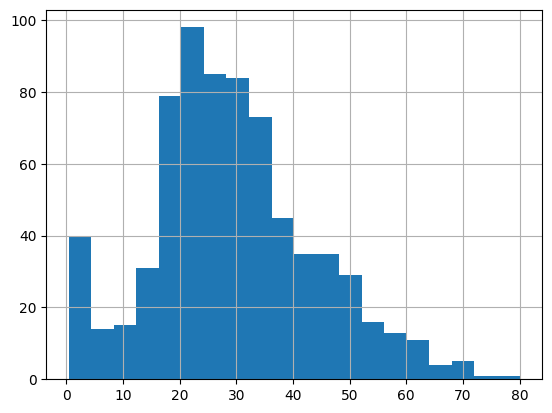

In [19]:
df["age"].hist(bins=20) # first, let´s explore with stastical values and histogram

In [20]:
df["age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

It has a near-normal distribution; the mean appears to be influenced by the maximum values, which skew it slightly, so the median might be a better measure of central tendency.

But BEWARE: we have a column closely linked to age (and gender) called ‘who’ (gender), so it would be wise to take this into account:

In [ ]:
df.groupby(['who'], observed=False)['age'].mean() # Average age for "who"

who
child     6.369518
man      33.173123
woman    32.000000
Name: age, dtype: float64

In [22]:
df.groupby(['who'], observed=False)['age'].median() # Average Median for Age of Median for "who"

who
child     5.0
man      30.0
woman    30.0
Name: age, dtype: float64

* We can see that the median changes slightly when we take gender into account, and it wouldn’t make sense to impute a value of 28 or 30 years to a child, would it? That’s why we’ve created an imputation strategy based on gender.

By the way, in cases like this, it might be useful to keep track of which data points were missing before imputation :)
We’ll do this using isna():

In [24]:
df["age_imputed"] = df.age.isna() # Columns with flags of imputacion

In [25]:
# Imputing the value for who in age:

# Maska by genre 
is_woman = df.who == "woman"
is_child = df.who == "child"
is_man = df.who == "man"

# Median Values
mediana_woman = df.loc[is_woman,"age"].median()
mediana_child = df.loc[is_child,"age"].median() 
mediana_man = df.loc[is_man,"age"].median()

# Imputing
df.loc[is_woman & df["age_imputed"], "age"] = mediana_woman
df.loc[is_child & df["age_imputed"], "age"] = mediana_child
df.loc[is_man & df["age_imputed"], "age"] = mediana_man

We can now see how the distribution changes with and without imputed values

<Axes: >

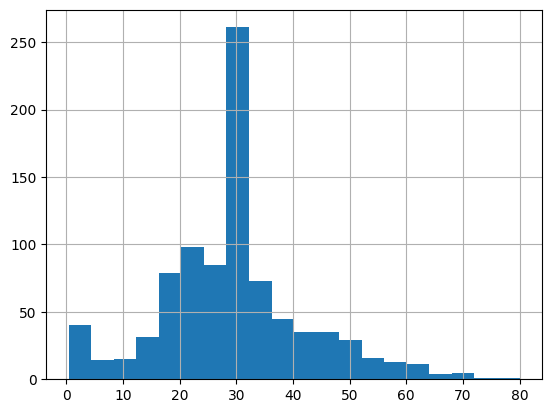

In [26]:
# Con valores imputados se observa como se dispara el valor de 30 años
df["age"].hist(bins=20)

<Axes: >

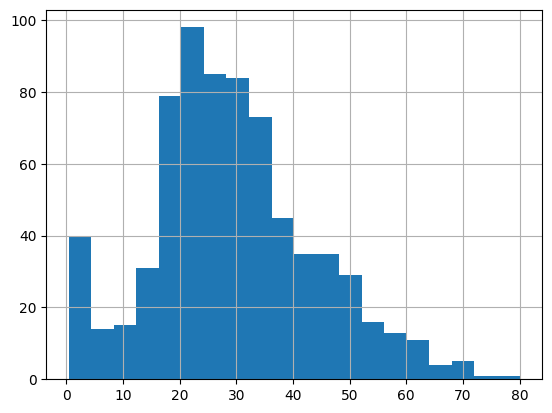

In [27]:
#  Sticking to the original distribution
df.loc[~df["age_imputed"], "age"].hist(bins=20)

In [28]:
df.isna().sum() # finding out if all null have been removed.

survived       0
pclass         0
sex            0
age            0
sibsp          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
age_imputed    0
dtype: int64

### #1.4
Sobre el dataset "limpio". Rellena la tabla de descripción (muy breve) de lo que es cada columna en función de su nombre y los valores. Para ayudarte:
* Se trata del dataset que reune lo más parecido a un manifiesto de supervivientes y fallecidos en el viaje.
* sibsp: Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros)
* embarked: Es la incial de la letra de la ciudad donde embarcó la persona.




| Columna/Variable | Descripción |
| ---------------- | ----------- |
| -       | - |




| Columna/Variable | Descripción |
| ---------------- | ----------- |
| survived         | Indica si el pasajero sobrevivió (1) o no (0) |
| pclass           | Clase del pasaje (1ª, 2ª, 3ª) |
| sex              | Género del pasajero |
| age              | Edad del pasajero |
| sibsp            | Es el numero de familiares que viajan con el pasajero indicado en el manifiesto (lista de pasajeros) |
| parch            | Número de padres/hijos a bordo |
| fare             | Tarifa pagada por el pasajero |
| embarked         | Es la inicial de la ciudad donde embarcó el pasajero (C = Cherbourg, Q = Queenstown, S = Southampton) |
| class            | Clase del pasaje como categoría (Primera, Segunda, Tercera) |
| who              | Categoría del pasajero (hombre, mujer, niño) |
| adult_male       | Booleano que indica si el pasajero es un hombre adulto |
| deck             | Cubierta del barco donde se alojaba el pasajero |
| embark_town      | Ciudad de embarque: Cherbourg, Queenstown, Southampton  |
| alive            | Indica si el pasajero está vivo ('yes') o muerto ('no') |
| alone            | Booleano que indica si el pasajero viajaba solo |

### #1.5

Busca en internet las tres ciudades que visitó el Titanic antes de poner rumbo a su destino y llegar a alta mar. Cambia las iniciales por esos valores.

We've already done that in the “embarked” column

In [29]:
df["embarked"].value_counts()

embarked
S    646
C    168
Q     77
Name: count, dtype: int64

### #2 Análisis

Sabiendo que el objetivo de nuestro análisis es hacer un estudio de la superviviencia y mortalidad en el viaje... Haz un análisis univariante completo y ordenado de las siguientes variables:
["survived","who","age","fare","class","embarked","alone"]
Nota: Si quieres añadir más, perfecto.

Separa el análisis en categóricas (incluyendo binarias) y numéricas. Muestra valores, gráficas y conclusiones/observaciones (2 o 3 por variable)

### #2.1 Categóricas

In [32]:
lista_variables = ["alive","who","age","fare","class","embarked","alone","sex"] # Creating a list with recomended variables and added sex

Let´s use function as under to differentiate between categorical and numerical variables:

In [31]:
# Primero dividir las variables por tipo, usando la función que programamos en los ejercicios
def card_tipo(df, umbral_categoria = 10, umbral_continua = 30):
    # Primera parte: Preparo el dataset con cardinalidades, % variación cardinalidad, y tipos
    df_temp = pd.DataFrame([df.nunique(), df.nunique()/len(df) * 100, df.dtypes]) # Cardinaliad y porcentaje de variación de cardinalidad
    df_temp = df_temp.T # Como nos da los valores de las columnas en columnas, y quiero que estas sean filas, la traspongo
    df_temp = df_temp.rename(columns = {0: "Card", 1: "%_Card", 2: "Tipo"}) # Cambio el nombre de la transposición anterior para que tengan más sentido, y uso asignación en vez de inplace = True (esto es arbitrario para el tamaño de este dataset)

    # Corrección para cuando solo tengo un valor
    df_temp.loc[df_temp.Card == 1, "%_Card"] = 0.00

    # Creo la columna de sugerenica de tipo de variable, empiezo considerando todas categóricas pero podría haber empezado por cualquiera, siempre que adapte los filtros siguientes de forma correspondiente
    df_temp["tipo_sugerido"] = "Categorica"
    df_temp.loc[df_temp["Card"] == 2, "tipo_sugerido"] = "Binaria"
    df_temp.loc[df_temp["Card"] >= umbral_categoria, "tipo_sugerido"] = "Numerica discreta"
    df_temp.loc[df_temp["%_Card"] >= umbral_continua, "tipo_sugerido"] = "Numerica continua"
    # Ojo los filtros aplicados cumplen con el enunciado pero no siguen su orden y planteamiento

    return df_temp

In [33]:
# La aplico sobre la vista de las variables seleccionadas para análisis
df_tipo = card_tipo(df[lista_variables], 10, 25)
df_tipo

,Card,%_Card,Tipo,tipo_sugerido
alive,2,0.224467,object,Binaria
who,3,0.3367,object,Categorica
age,88,9.876543,float64,Numerica discreta
fare,248,27.833895,float64,Numerica continua
class,3,0.3367,category,Categorica
embarked,3,0.3367,object,Categorica
alone,2,0.224467,bool,Binaria
sex,2,0.224467,object,Binaria


In [35]:
# Separo en categóricas y numéricas (a mano)

categoricas = ["alive", "who", "class", "embarked", "alone", "sex"]
numericas = ["age", "fare"]

In [36]:
# Separo en categóricas y numéricas (con pandas)

categoricas = df[lista_variables].columns[df_tipo["tipo_sugerido"].isin(["Binaria","Categorica"])].to_list()
numericas = df[lista_variables].columns[df_tipo["tipo_sugerido"].isin(["Numerica discreta","Numerica continua"])].to_list()

In [37]:
print(f"Variables categóricas: {categoricas}")
print(f"Variables numéricas: {numericas}")

Variables categóricas: ['alive', 'who', 'class', 'embarked', 'alone', 'sex']
Variables numéricas: ['age', 'fare']


### #2.2 Numéricas

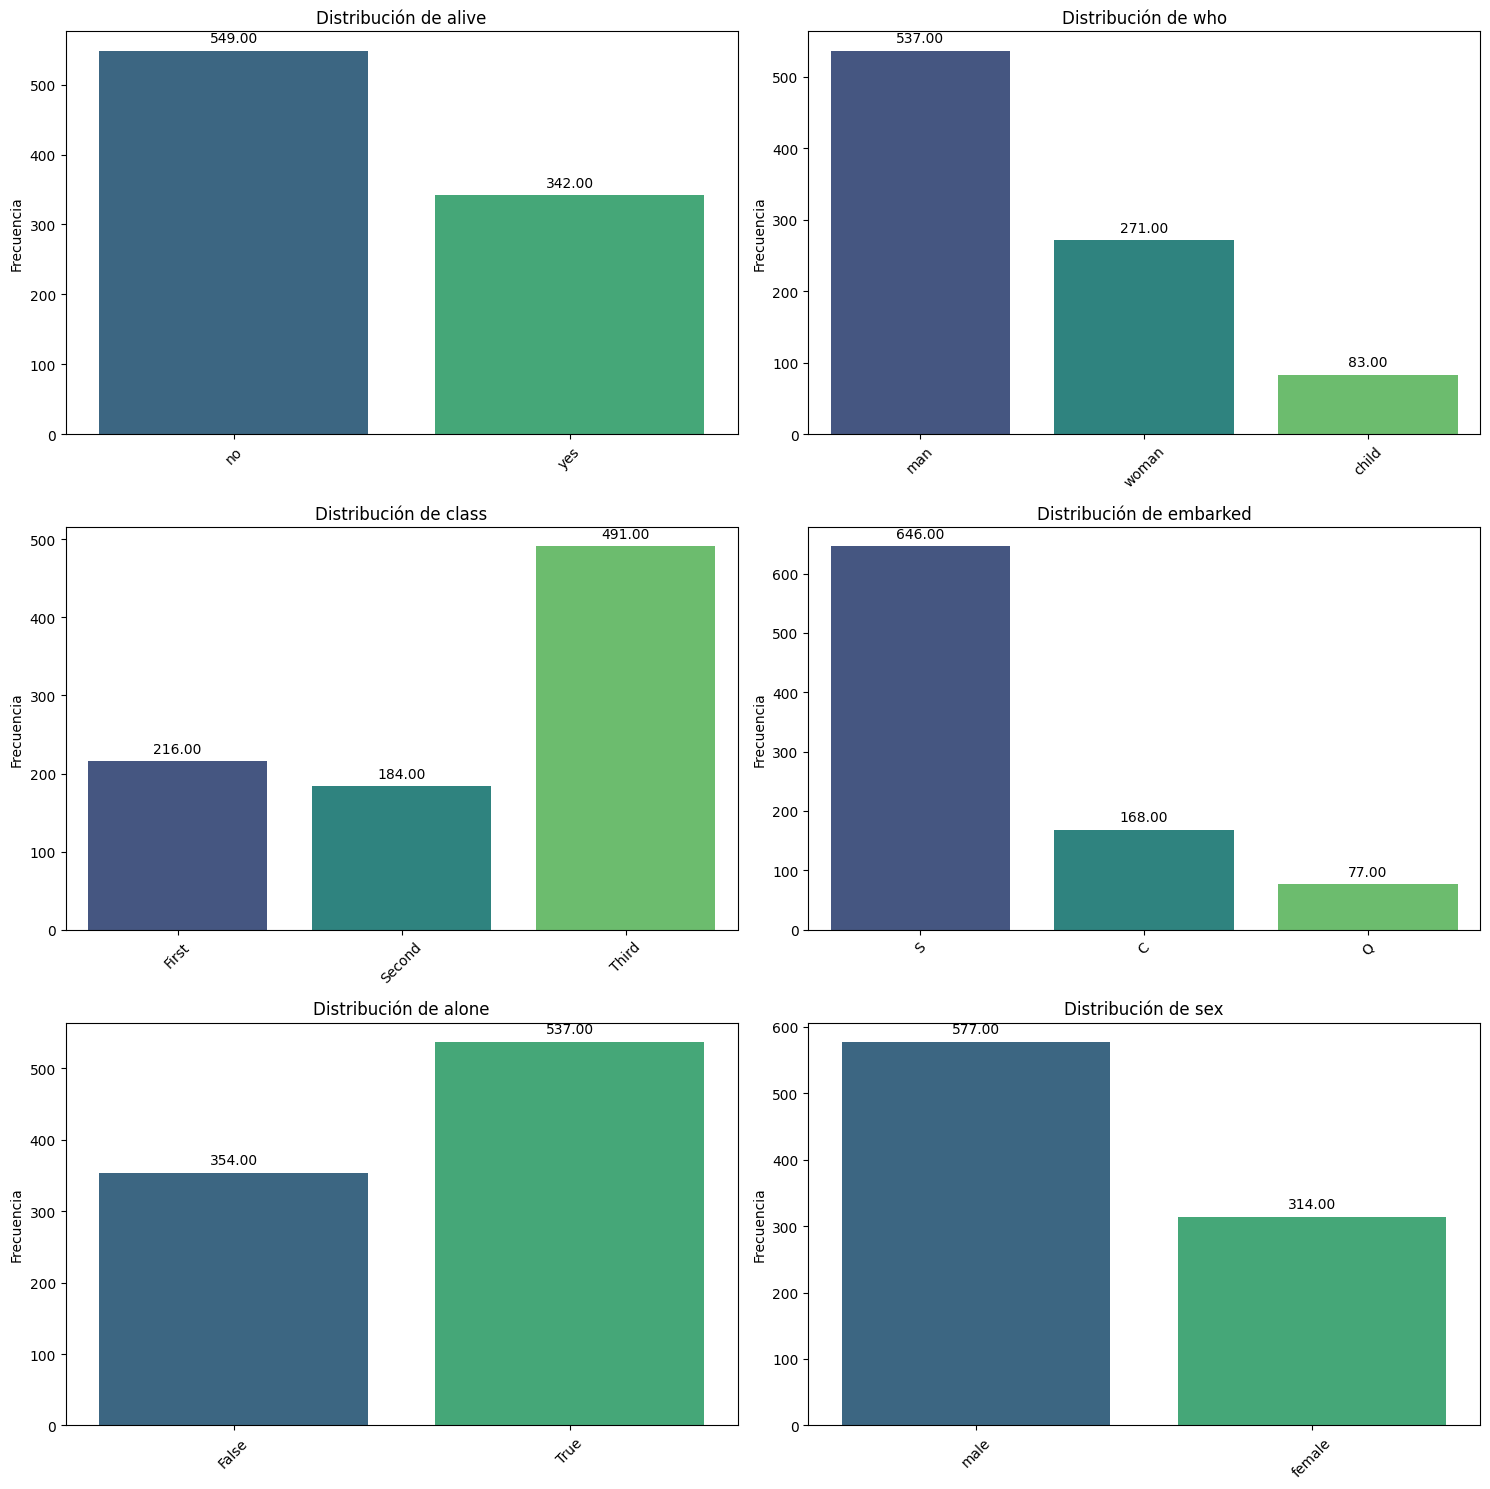

In [38]:
pinta_distribucion_categoricas(df, categoricas, mostrar_valores= True)

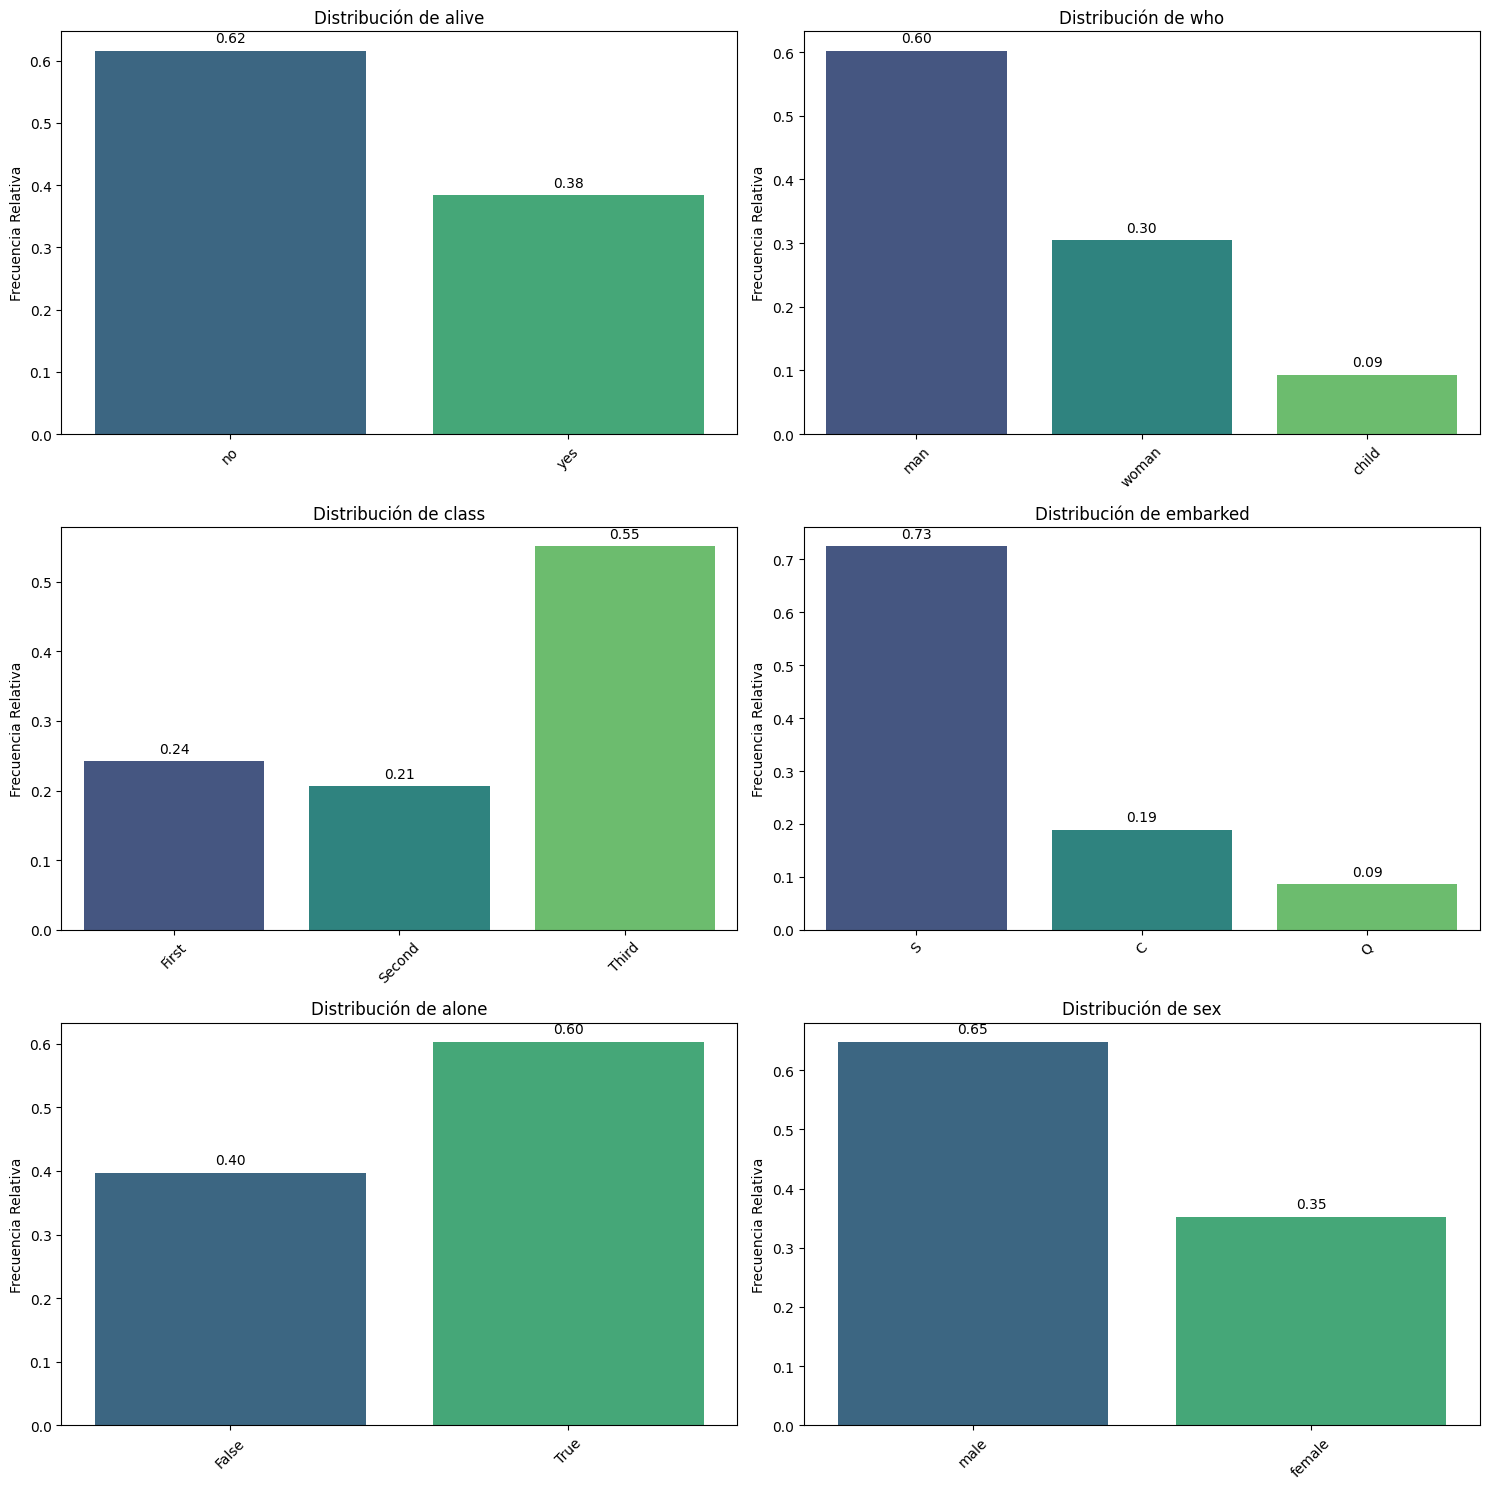

In [39]:
pinta_distribucion_categoricas(df, categoricas, relativa=True, mostrar_valores= True) # Analysing the relative frequency

### #2.2 Numéricas

In [40]:
df[numericas].describe() # statistical values

,age,fare
count,891.000000,891.000000
mean,29.758889,32.204208
std,13.002570,49.693429
min,0.420000,0.000000
25%,22.000000,7.910400
50%,30.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


In [41]:
(31 - 7.9104) * 1.5

34.6344

*Calculating ICR and CV*

#### Interquartile of the variables (IQR)

***age***

>IQR = Q3 - Q1 = 35 - 22 = 13
>
>1.5 * IQR = 1.5 * 13 = 19.5
>
>maximum = min(Q3 + 1.5*IQR, max) = min(35 + 19.5, 80) = 54.5
>
>minimum = max(Q1 - 1.5*IQR, min) = max(22 - 19.5, 0.42) = 2.5

***fare***

>IQR = Q3 - Q1 = 31 - 7.9104 = 23.0896
>
>1.5 * IQR = 1.5 * 23.0896 = 34.6344
>
>maximum = min(Q3 + 1.5*IQR, max) = min(31 + 34.6344, 512.3292) = 54.5
>
>minimum = max(Q1 - 1.5*IQR, min) = max(7.9104 - 34.6344, 0) = 2.5

#### Coeficient of variacion (CV)

More info: [Wikipedia](https://es.wikipedia.org/wiki/Coeficiente_de_variaci%C3%B3n)

In [ ]:
# Obtenemos sus CV con una función

def get_CV(df, columna):
    columna = [columna] if isinstance(columna, str) else columna
    desc = df[columna].describe().T
    return desc["std"] / desc["mean"] * 100

In [ ]:
# Le puedo pasar a la función una lista o un string (columna a columna)

get_CV(df, numericas)
# get_CV(df,"age")
# get_CV(df,"fare")

These coefficients of variation indicate very different levels of dispersion across each variable:

***age: 43.69%***
- Moderate dispersion
- This is reasonable for ages: there were babies, adults and elderly people on the Titanic
- The data **is not homogeneous**, but is relatively concentrated around the mean

***fare: 154.31%***

- Very high dispersion (over 100%)
- This means that the standard deviation is greater than the mean.
- It indicates **highly heterogeneous** data: there were probably very cheap fares (3rd class) and very expensive ones (1st class, luxury suites)
- There may be significant outliers

(2, 2)


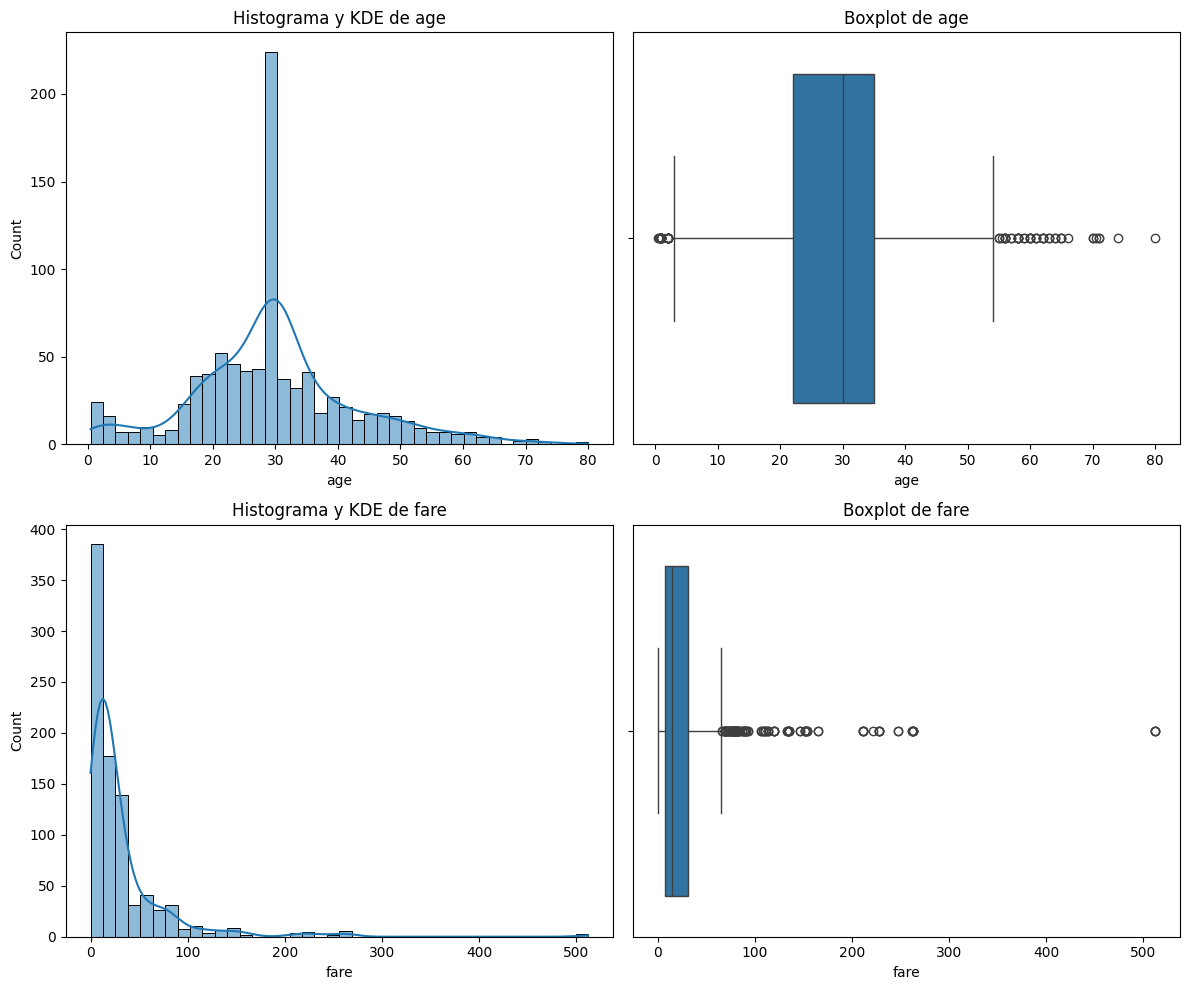

In [42]:
# Finally, we plot histogramas and box diágrams

plot_combined_graphs(df, numericas, whisker_width=1.5, bins = 40)

(2, 2)


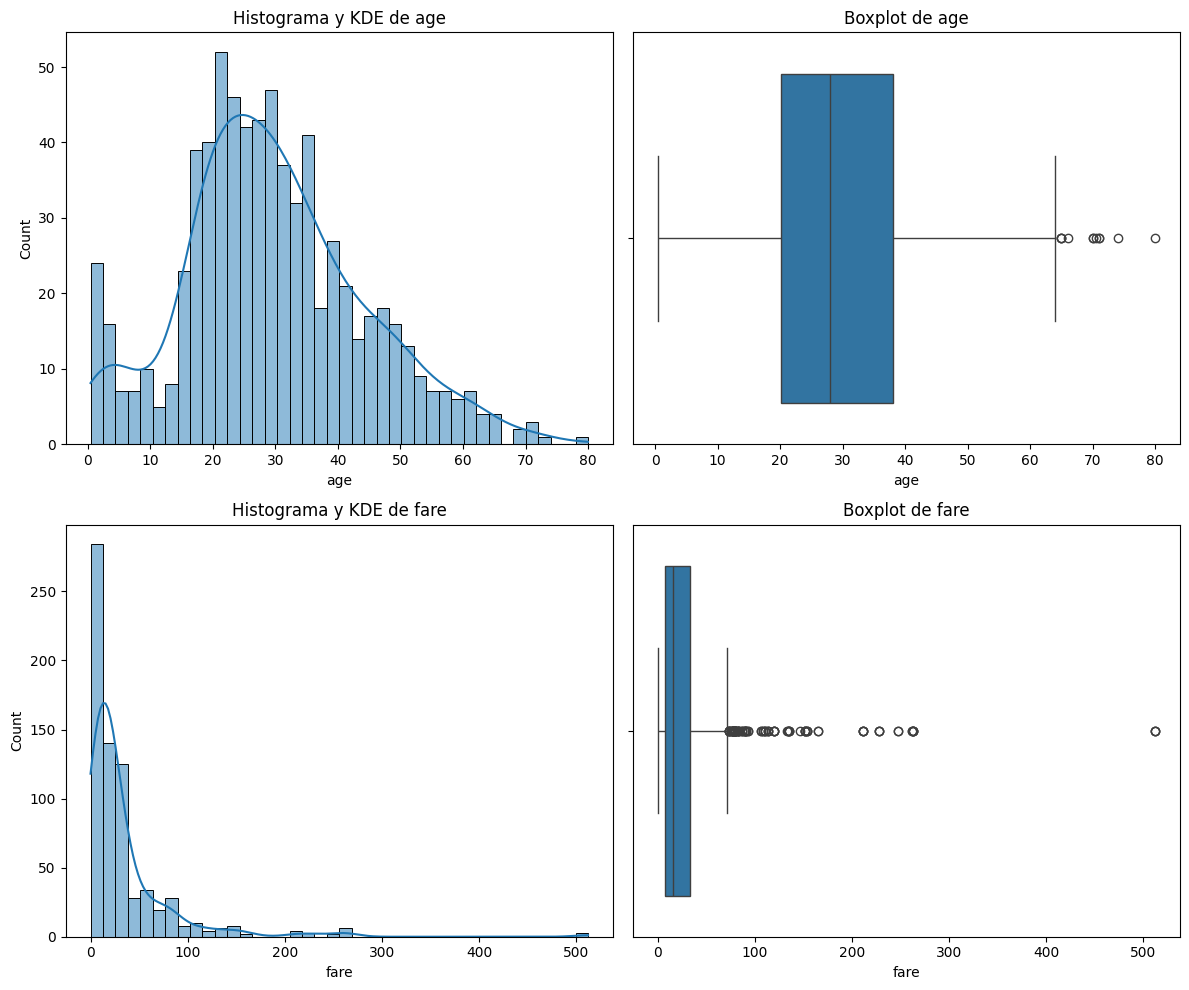

In [43]:
plot_combined_graphs(df[~df["age_imputed"]], numericas, whisker_width=1.5, bins = 40) # deleting null entries in age

#### ***Numerical Univariate Analysis***:

***age***:
- It produces a nice, almost-normal graph, indicating symmetry and good representation by the central tendencies (perhaps the median is again a better measure than the mean, although they are close), although there is some dispersion (CV > 30%). There are possible outliers above and below (but in this case these will be babies and older adults). To note the values (mean: 32, median: 30). As I already know that the ‘who’ variable exists, I note an interesting analysis that could be ‘age’/‘who’, and of course ‘age’/‘class’. In general, ‘age’ is useful for better understanding the data and then relating it multivariately to ‘survived’.

***fare***:
* The ticket price shows a completely different distribution curve, as was almost to be expected, and if we link it to other observations such as customer_lifetime_value, it may be quite characteristic of prices, income, expenditure on services, etc. It is a distribution with concentration (the range is narrow) and a long tail (as can be seen in the existence of quite a few values that could be considered outliers). The mean seems unrepresentative, and we would opt for the median as a more representative value (from 32 to 14 pounds?), but it will certainly be interesting to perhaps treat this variable as a candidate for *binning* and relate it to *class*, which might already save us that *binning* and even the need to use this column.